# Incident (grounding/sinking) of a vessel blocking a major port

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import glob
import os

In [3]:
pd.set_option('display.max_rows', 500)

In [4]:
from vista_criticality_utils import *

In [5]:
# Reload modules
import importlib
import vista_criticality_utils
importlib.reload(vista_criticality_utils)
from vista_criticality_utils import *

# 1. Load assets to a new graph

In [6]:
asset_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/03-data-vessel-blocking-port.csv'
dependency_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/03-ferry-dependency.csv'

In [7]:
incident_data = pd.read_csv(asset_file)
dependency_data = pd.read_csv(dependency_file)

In [8]:
incident_data.head(100)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03


In [9]:
incident_data.shape

(133, 7)

In [10]:
dependency_data.head(10)

,from_asset,to_asset,connection,dependency_score
0,PGS06,TRF02,PGS06-->TRF02,3
1,PGS03,TRF01,PGS03-->TRF01,3
2,TRF02,PH04,TRF02-->PH04,3
3,TRF02,JN27,TRF02-->JN27,3
4,JN27,JN01,JN27-->JN01,3
5,TRF01,JN05,TRF01-->JN05,2
6,JN05,JN11,JN05-->JN11,3
7,TRF02,JN08,TRF02-->JN08,3
8,TRF02,HS01,TRF02-->HS01,3
9,TRF01,HS01,TRF01-->HS01,2


In [11]:
dependency_data.shape

(47, 4)

In [12]:
G = load_assets_to_graph(assets_filepath=asset_file)

Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/03-data-vessel-blocking-port.csv
Added 133 nodes to the graph.


In [13]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working'}

# 2. Add Dependencies to Graph

In [14]:
G = add_dependencies_to_graph(graph=G, dependencies_filepath=dependency_file)


Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/03-ferry-dependency.csv
Added edges. The graph now has 47 edges.


In [15]:
## Add dependency score as node attributes
G = compute_dependency_score(G=G)

In [16]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 3}

In [17]:
incident_data = graph_to_dataframe(G)

In [18]:
incident_data.head(20) # Assets now with dependenc scores

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0


# 3. Exposure Score

In [19]:
flood_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/flood_files'
heat_stress_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/heat_stress_files'
landslide_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/landslide_files'

In [20]:
# Construct the search pattern to find all .geojson files in the specified folder
flood_geojson_search_pattern = os.path.join(flood_layers, '*.geojson')
flood_geojson_file_paths = glob.glob(flood_geojson_search_pattern)

heat_geojson_search_pattern = os.path.join(heat_stress_layers, '*.geojson')
heat_geojson_file_paths = glob.glob(heat_geojson_search_pattern)

landslide_geojson_search_pattern = os.path.join(landslide_layers, '*.geojson')
landslide_geojson_file_paths = glob.glob(landslide_geojson_search_pattern)

In [21]:
incident_data = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths)
incident_data.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,2
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,2
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [22]:
## Export data with exposure scores
# incident_data.to_csv('exposure_score_with_flood_layer.csv', index=False)

In [23]:
incident_data_with_heat_stress_layer = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths)

In [24]:
incident_data_with_heat_stress_layer.head(20) # Exposure

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,3
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,3
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [25]:
# incident_data_with_heat_stress_layer.to_csv('exposure_score_with_flood_heat_layer.csv', index=False)

In [26]:
incident_data_with_heat_stress_landslide_layer= compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths, landslide_files=landslide_geojson_file_paths)

In [27]:
incident_data_with_heat_stress_landslide_layer.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,3
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,3
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [28]:
#incident_data_with_heat_stress_landslide_layer.to_csv('exposure_score_with_flood_heat_landslide_layer.csv',index=False)

In [29]:
incident_data = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths)
incident_data.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,2
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,2
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


# 4. Redundancy Score

In [30]:
incident_data = compute_redundancy_score(df=incident_data)

In [31]:
incident_data.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,2,2
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0,2
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0,2
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2,3
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0,3
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0,1
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0,3
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,2,3
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1,0


### Add exposure and redundancy scores as graph node addtributes

In [32]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='exposure_score')

Added exposure_score to the graph.


In [33]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 3,
 'exposure_score': 1}

In [34]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='redundancy_score')

Added redundancy_score to the graph.


In [35]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 3,
 'exposure_score': 1,
 'redundancy_score': 1}

# 5. Compute Asset Score

In [36]:
G = compute_asset_score(G=G)

Added asset_score to assets.


In [37]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 3,
 'exposure_score': 1,
 'redundancy_score': 1,
 'asset_score': 8}

# 6. Simulate failure

In [39]:
failed_nodes = simulate_failure(G=G, failed_node='TRF02')

Failing: TRF02
Propagated failure to: JN06 (via dependency 3.0)
Propagated failure to: JN26 (via dependency 3.0)
Propagated failure to: PH04 (via dependency 3.0)
Propagated failure to: JN01 (via dependency 3.0)
Propagated failure to: JN32 (via dependency 3.0)
Propagated failure to: JN27 (via dependency 3.0)
Propagated failure to: HS01 (via dependency 3.0)
Propagated failure to: JN07 (via dependency 3.0)
Propagated failure to: JN30 (via dependency 3.0)
Propagated failure to: JN08 (via dependency 3.0)
Propagated failure to: PH02 (via dependency 3.0)


In [40]:
len(failed_nodes)

11

Initiating failure at node: TRF02
Propagated failure to: JN06 (dependency: 3.00 >= 1)
Propagated failure to: JN26 (dependency: 3.00 >= 1)
Propagated failure to: PH04 (dependency: 3.00 >= 1)
Propagated failure to: JN01 (dependency: 3.00 >= 1)
Propagated failure to: JN32 (dependency: 3.00 >= 1)
Propagated failure to: JN27 (dependency: 3.00 >= 1)
Propagated failure to: HS01 (dependency: 3.00 >= 1)
Propagated failure to: JN07 (dependency: 3.00 >= 1)
Propagated failure to: JN30 (dependency: 3.00 >= 1)
Propagated failure to: JN08 (dependency: 3.00 >= 1)
Propagated failure to: PH02 (dependency: 3.00 >= 1)


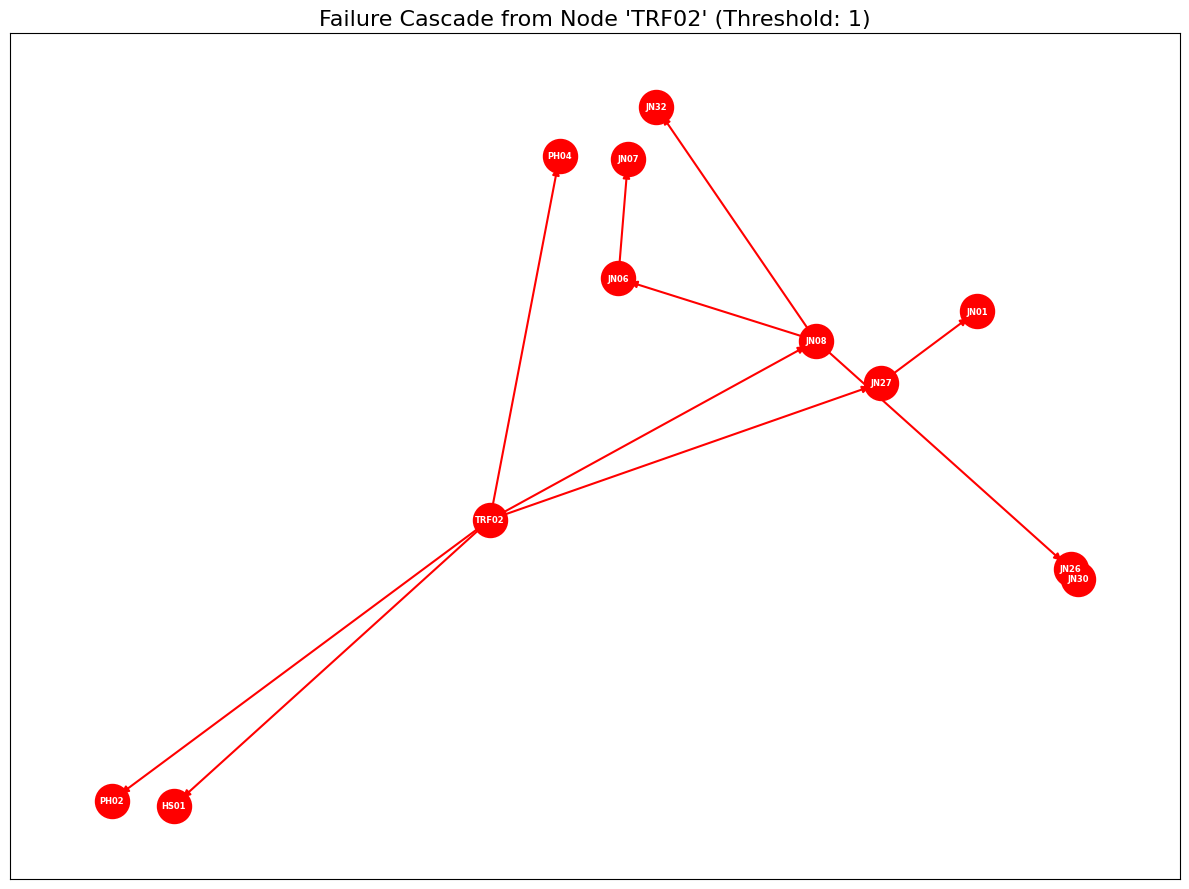

(['JN06',
  'JN26',
  'PH04',
  'JN01',
  'JN32',
  'JN27',
  'HS01',
  'JN07',
  'JN30',
  'JN08',
  'PH02'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'TRF02' (Threshold: 1)"}>))

In [41]:
simulate_failure_with_plot(G, failed_node='TRF02', threshold=1)

In [42]:
check_node_and_edges(G, 'TRF02')


--- Analysis for Node: TRF02 ---

[Asset Attributes]
  - Asset_ID: TRF02
  - Asset_Type: Transport-Ferry
  - Asset_Name: FerryPort
  - lat: 50.763106
  - long: -1.2960338
  - criticality_score: 3
  - backup_asset_id: TRF01
  - status: failed
  - dependency_score: 3
  - exposure_score: 0
  - redundancy_score: 0
  - asset_score: 6

[Outgoing Dependencies (This asset depends on...)]
  -> TRF02 impacts PH04 with dependency_score (weight): 3.0
  -> TRF02 impacts JN27 with dependency_score (weight): 3.0
  -> TRF02 impacts JN08 with dependency_score (weight): 3.0
  -> TRF02 impacts HS01 with dependency_score (weight): 3.0
  -> TRF02 impacts PH02 with dependency_score (weight): 3.0

[Incoming Dependencies (...depend on this asset)]
  <- PGS06 is parent to TRF02 with dependency_score (weight): 3.0
------------------------------


# 7. Filter Graph by Criticality

In [43]:
G_criticality = filter_graph_by_criticality(G, threshold=3)


Filtered graph by criticality score >= 3.


In [44]:
G_criticality.number_of_nodes()

92

In [45]:
G_criticality.number_of_edges()

36

In [46]:
check_node_and_edges(G, 'TRF02')


--- Analysis for Node: TRF02 ---

[Asset Attributes]
  - Asset_ID: TRF02
  - Asset_Type: Transport-Ferry
  - Asset_Name: FerryPort
  - lat: 50.763106
  - long: -1.2960338
  - criticality_score: 3
  - backup_asset_id: TRF01
  - status: failed
  - dependency_score: 3
  - exposure_score: 0
  - redundancy_score: 0
  - asset_score: 6

[Outgoing Dependencies (This asset depends on...)]
  -> TRF02 impacts PH04 with dependency_score (weight): 3.0
  -> TRF02 impacts JN27 with dependency_score (weight): 3.0
  -> TRF02 impacts JN08 with dependency_score (weight): 3.0
  -> TRF02 impacts HS01 with dependency_score (weight): 3.0
  -> TRF02 impacts PH02 with dependency_score (weight): 3.0

[Incoming Dependencies (...depend on this asset)]
  <- PGS06 is parent to TRF02 with dependency_score (weight): 3.0
------------------------------


In [47]:
G_criticality.nodes()

NodeView(('WS01', 'SW01', 'SW02', 'SW03', 'SW04', 'PGS01', 'PGS02', 'PGS03', 'PGS04', 'WS02', 'WS03', 'WS04', 'WS05', 'PGS05', 'TEL01', 'TEL02', 'TEL03', 'TEL04', 'TEL05', 'TEL06', 'TEL07', 'TEL08', 'TEL09', 'TEL10', 'TEL11', 'PGS06', 'PGS07', 'PGS08', 'TRF01', 'TRF02', 'TRF03', 'TRF04', 'TRR01', 'TRR02', 'TRR03', 'TRR04', 'TRR05', 'TRR06', 'TRR07', 'TRR08', 'TRR09', 'TRR10', 'TRA01', 'TRA02', 'TRB01', 'TRB02', 'TRB03', 'TRB04', 'TRB05', 'TRB06', 'TRB07', 'HS01', 'VH01', 'VH02', 'VH03', 'VH04', 'VH05', 'GS01', 'JN01', 'JN02', 'JN03', 'JN04', 'JN05', 'JN06', 'JN07', 'JN08', 'JN09', 'JN10', 'JN11', 'JN12', 'JN13', 'JN14', 'JN15', 'JN16', 'JN17', 'JN18', 'JN19', 'JN20', 'JN21', 'JN22', 'JN23', 'JN24', 'JN25', 'JN26', 'JN27', 'JN28', 'JN29', 'JN30', 'JN31', 'JN32', 'JN33', 'JN34'))

Initiating failure at node: TRF02
Propagated failure to: JN06 (dependency: 3.00 >= 1.0)
Propagated failure to: JN26 (dependency: 3.00 >= 1.0)
Propagated failure to: JN01 (dependency: 3.00 >= 1.0)
Propagated failure to: JN32 (dependency: 3.00 >= 1.0)
Propagated failure to: JN27 (dependency: 3.00 >= 1.0)
Propagated failure to: HS01 (dependency: 3.00 >= 1.0)
Propagated failure to: JN07 (dependency: 3.00 >= 1.0)
Propagated failure to: JN30 (dependency: 3.00 >= 1.0)
Propagated failure to: JN08 (dependency: 3.00 >= 1.0)


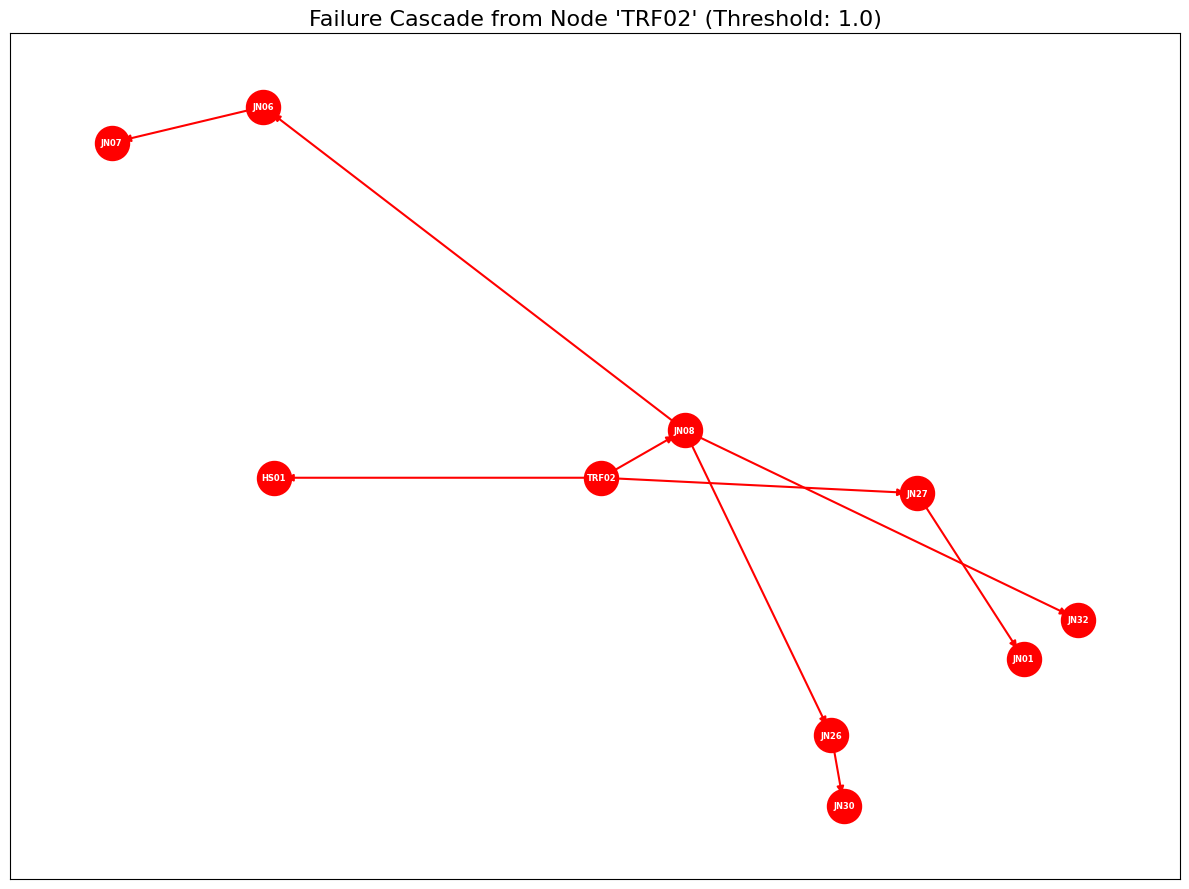

(['JN06', 'JN26', 'JN01', 'JN32', 'JN27', 'HS01', 'JN07', 'JN30', 'JN08'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'TRF02' (Threshold: 1.0)"}>))

In [49]:
simulate_failure_with_plot(G_criticality, 'TRF02') #Only Criticality 3 assets shown

# 8. Add new assets and connections to network

In [50]:
new_asset_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/additional-new-assets.csv'
new_asset_mapping_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/additional-new-assets-mapping.csv'

In [51]:
new_assets = pd.read_csv(new_asset_file)
new_dependencies = pd.read_csv(new_asset_mapping_file)

In [52]:
new_assets.head()

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id
0,PGS09,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.703494,-1.292065,3,NaN
1,LFS01,LiquidFuelStorage,LiquidFuelStorageComplex,50.748784,-1.288094,2,LFS02
2,LFS02,LiquidFuelStorage,LiquidFuelStorageComplex,50.745210,-1.287311,2,LFS03
3,LFS03,LiquidFuelStorage,LiquidFuelStorageComplex,50.755962,-1.292791,2,LFS01
4,TEL12,Telecomms,TelecommunicationsExchange,50.730509,-1.164576,3,NaN


In [53]:
new_dependencies.head(10)

,from_asset,to_asset,connection,dependency_score
0,PGS09,LFS02,PGS09-->LFS02,3
1,PGS09,LFS01,PGS09-->LFS01,3
2,PGS09,LFS03,PGS09-->LFS03,3
3,PGS09,TEL12,PGS09-->TEL12,3


In [54]:
G_assets = G.copy()

In [55]:
G_assets.number_of_nodes()


133

In [56]:
G_new_nodes =  add_new_assets_to_graph(G, new_assets)

Added 5 new assets and updated 0 existing assets.


In [57]:
G_new_nodes.number_of_nodes()


138

In [58]:
G_new_nodes = add_new_dependency_to_graph(G_new_nodes, new_dependencies)

Added 4 new dependencies.


In [59]:
G_new_nodes.number_of_edges()

51

In [60]:
G_new_nodes = add_dependencies_to_graph(G_new_nodes, new_asset_mapping_file)


Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/additional-new-assets-mapping.csv
Added edges. The graph now has 51 edges.


In [61]:
check_node_and_edges(G_new_nodes, 'PGS09')


--- Analysis for Node: PGS09 ---

[Asset Attributes]
  - Asset_ID: PGS09
  - Asset_Type: PowerGen/Substation
  - Asset_Name: LowVoltageElectricitySubstationComplex
  - lat: 50.703494
  - long: -1.2920646
  - criticality_score: 3
  - backup_asset_id: nan
  - dependency_score: 3

[Outgoing Dependencies (This asset depends on...)]
  -> PGS09 impacts LFS02 with dependency_score (weight): 3.0
  -> PGS09 impacts LFS01 with dependency_score (weight): 3.0
  -> PGS09 impacts LFS03 with dependency_score (weight): 3.0
  -> PGS09 impacts TEL12 with dependency_score (weight): 3.0

[Incoming Dependencies (...depend on this asset)]
  - None
------------------------------


Initiating failure at node: PGS09
Propagated failure to: LFS02 (dependency: 3.00 >= 1.0)
Propagated failure to: TEL12 (dependency: 3.00 >= 1.0)
Propagated failure to: LFS03 (dependency: 3.00 >= 1.0)
Propagated failure to: LFS01 (dependency: 3.00 >= 1.0)


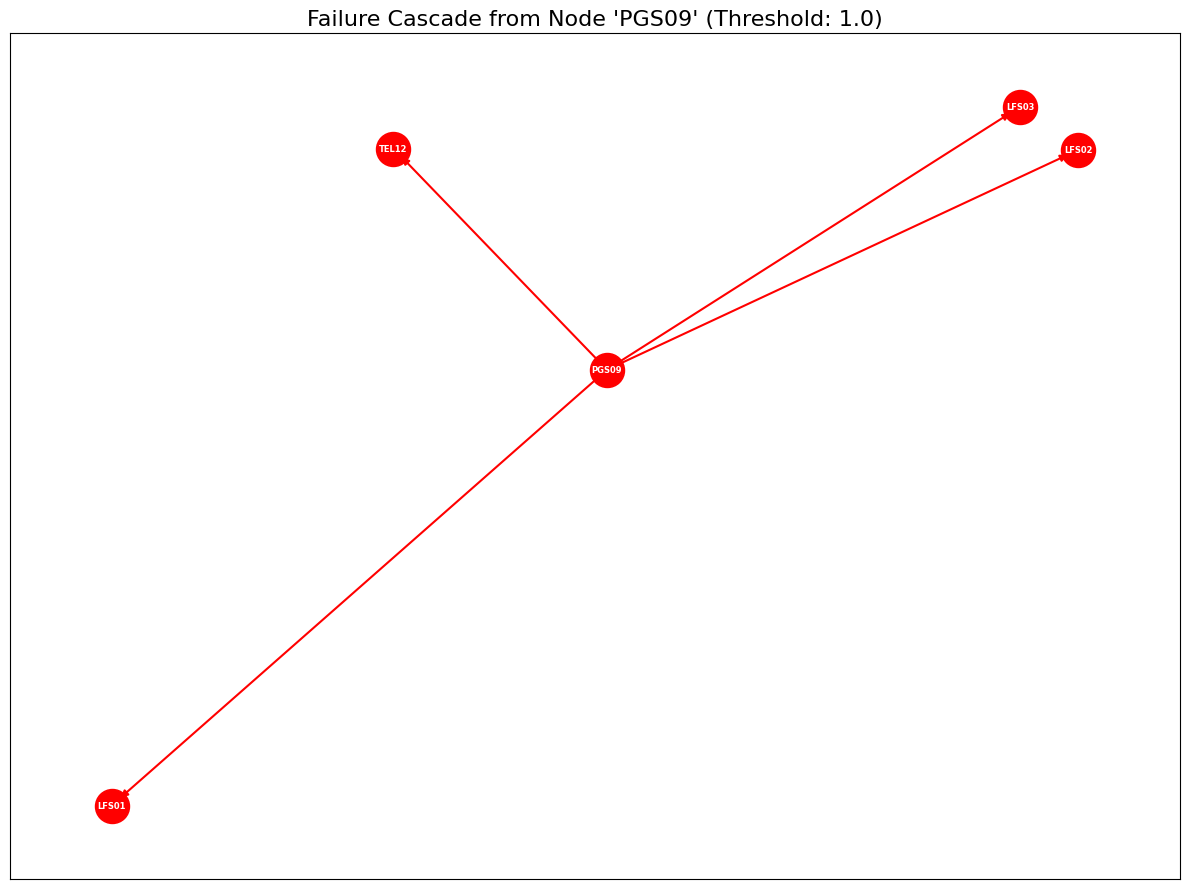

(['LFS02', 'TEL12', 'LFS03', 'LFS01'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'PGS09' (Threshold: 1.0)"}>))

In [62]:
simulate_failure_with_plot(G_new_nodes, 'PGS09')

In [63]:
incident_data_with_new_nodes = graph_to_dataframe(G_new_nodes)

In [64]:
incident_data_with_new_nodes.shape

(138, 12)

In [65]:
incident_data_with_new_nodes.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score,asset_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0.0,2.0,2.0,7.0
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0.0,0.0,2.0,5.0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0.0,0.0,2.0,5.0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0.0,2.0,3.0,8.0
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0.0,0.0,3.0,6.0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,failed,3.0,1.0,1.0,8.0
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0.0,0.0,1.0,4.0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3.0,0.0,3.0,9.0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0.0,2.0,3.0,8.0
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0.0,1.0,0.0,4.0


In [66]:
G_new_nodes.nodes['PGS09']


{'Asset_ID': 'PGS09',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.703494,
 'long': -1.2920646,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'dependency_score': 3,
 'status': 'failed'}

In [67]:
incident_data_with_new_nodes = compute_exposure_score(assets_df=incident_data_with_new_nodes, flood_files=flood_geojson_file_paths)
incident_data_with_new_nodes = compute_redundancy_score(df=incident_data_with_new_nodes)

In [68]:
# incident_data_with_new_nodes.head(110)

In [69]:
G_new_nodes = add_attribute_from_df(G=G_new_nodes, df=incident_data_with_new_nodes, column_name='exposure_score')
G_new_nodes = add_attribute_from_df(G=G, df=incident_data_with_new_nodes, column_name='redundancy_score')

Added exposure_score to the graph.
Added redundancy_score to the graph.


In [70]:
G_new_nodes = compute_asset_score(G=G_new_nodes)

Added asset_score to assets.


In [71]:
G_new_nodes.nodes['PGS09']

{'Asset_ID': 'PGS09',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.703494,
 'long': -1.2920646,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'dependency_score': 3,
 'status': 'failed',
 'exposure_score': 1,
 'redundancy_score': 3,
 'asset_score': 10}

In [72]:
new_assets_all_scores = graph_to_dataframe(G_new_nodes)

In [73]:
new_assets_all_scores


,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score,asset_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0.0,2,2,7
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0.0,0,2,5
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0.0,0,2,5
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0.0,2,3,8
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0.0,0,3,6
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,failed,3.0,1,1,8
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0.0,0,1,4
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3.0,0,3,9
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0.0,2,3,8
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0.0,1,0,4


In [71]:
G_new_nodes.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'failed',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 3,
 'asset_score': 9}

In [ ]:
G_new_nodes.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'failed',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 3,
 'asset_score': 9}